<a href="https://colab.research.google.com/github/Naincy-20-06/Machine_Learning_projects/blob/Naincy-20-06-patch-1/GPA_KM_C_H_C_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 1: Data Preprocessing and Feature Engineering

### Data Import and Initial Exploration

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
try:
    df = pd.read_csv('Global_Pollution_Analysis.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'Global_Pollution_Analysis.csv' not found. Please ensure the file is in the correct directory.")
    # Create a dummy DataFrame for demonstration if the file is not found
    data = {
        'Country': ['USA', 'China', 'India', 'Germany', 'Brazil'],
        'Year': [2000, 2000, 2000, 2000, 2000],
        'Air_Pollution_Index': [50.0, 80.0, 120.0, 30.0, 60.0],
        'Water_Pollution_Index': [30.0, 70.0, 90.0, 20.0, 40.0],
        'Soil_Pollution_Index': [20.0, 60.0, 80.0, 10.0, 30.0],
        'Industrial_Waste (in tons)': [1000.0, 5000.0, 3000.0, 800.0, 1500.0],
        'Energy_Recovered (in GWh)': [500.0, 200.0, 100.0, 400.0, 150.0],
        'CO2_Emissions (in MT)': [18.0, 5.0, 1.0, 9.0, 2.0],
        'Renewable_Energy (%)': [10.0, 20.0, 5.0, 30.0, 15.0],
        'Plastic_Waste_Produced (in tons)': [500.0, 2000.0, 1000.0, 300.0, 700.0],
        'Energy_Consumption_Per_Capita (in MWh)': [8.0, 3.0, 1.0, 5.0, 2.0],
        'Population (in millions)': [280.0, 1260.0, 1000.0, 80.0, 170.0],
        'GDP_Per_Capita (in USD)': [40000.0, 8000.0, 2000.0, 35000.0, 10000.0]
    }
    df = pd.DataFrame(data)
    print("Created a dummy DataFrame for demonstration.")

# Display the first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Get information about the dataset, including data types and non-null values
print("\nDataset Info:")
df.info()

# Check for missing values
print("\nMissing values before handling:")
display(df.isnull().sum().sort_values(ascending=False))

Dataset loaded successfully.

First 5 rows of the dataset:


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


### Handle Missing Data

In [ ]:
# For numerical columns, impute with the mean.
numerical_cols = [
    'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index',
    'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)', 'Energy_Recovered (in GWh)',
    'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
    'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)', 'GDP_Per_Capita (in USD)'
]
for col in numerical_cols:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())
        print(f"Missing values in '{col}' imputed with mean.")

# For categorical columns, if any, we might impute with the mode or a placeholder. Assuming 'Country' and 'Year' are complete or will be handled by encoding.
# For now, let's verify if any other columns have missing values after numerical imputation.
print("\nMissing values after imputation:")
display(df.isnull().sum().sort_values(ascending=False))
print("\nDataFrame head after handling missing data:")
display(df.head())


Missing values after imputation:


,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0



DataFrame head after handling missing data:


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


### Normalize/Scale Pollution Indices and other Numerical Features

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Define the columns to be normalized/scaled.
scaling_cols = [
    'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index',
    'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)', 'Population (in millions)',
    'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
    'Energy_Consumption_Per_Capita (in MWh)', 'GDP_Per_Capita (in USD)'
]

# Check if columns exist before scaling
actual_scaling_cols = [col for col in scaling_cols if col in df.columns]

if actual_scaling_cols:
    df[actual_scaling_cols] = scaler.fit_transform(df[actual_scaling_cols])
    print(f"Columns scaled: {actual_scaling_cols}")
else:
    print("No relevant columns found for scaling.")

# Display the first few rows of the DataFrame after scaling to verify
print("\nFirst 5 rows after scaling numerical features:")
display(df.head())
print("\nDataFrame describe after scaling numerical features:")
display(df.describe())

Columns scaled: ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)', 'Population (in millions)', 'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)', 'Energy_Consumption_Per_Capita (in MWh)', 'GDP_Per_Capita (in USD)']

First 5 rows after scaling numerical features:


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,1.376167,0.193880,-0.619764,1.543328,158.14,-1.356325,1.079423,0.874923,0.561742,-1.093143,-0.737646
1,Singapore,2001,-1.403578,-1.153098,1.028744,0.124915,498.04,-1.284276,0.700701,0.600289,-0.756197,0.580978,-0.023527
2,Romania,2016,-1.330788,-0.668076,1.142400,0.123888,489.51,1.718910,-1.493780,-0.395504,0.667825,0.355836,1.156054
3,Cook Islands,2018,1.494394,-1.009403,0.431675,0.809131,145.18,-1.106232,-0.716061,-1.064327,-1.556310,-0.642506,-0.693157
4,Djibouti,2008,-0.021926,0.262567,1.138106,0.882681,40.38,-0.689181,0.502825,1.024815,0.612087,1.448956,0.312447



DataFrame describe after scaling numerical features:


,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,2009.335000,7.549517e-17,-3.552714e-16,2.486900e-16,-2.220446e-16,260.448700,1.776357e-17,1.842970e-16,-3.774758e-17,-8.881784e-17,-1.931788e-16,-1.776357e-16
std,5.765325,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,147.141923,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00
min,2000.000000,-1.947928e+00,-1.768540e+00,-1.650240e+00,-1.910136e+00,11.730000,-1.590483e+00,-1.845740e+00,-1.664895e+00,-1.601260e+00,-1.796052e+00,-1.750064e+00
25%,2004.000000,-6.823730e-01,-8.536990e-01,-8.989775e-01,-7.986976e-01,118.355000,-9.462011e-01,-8.190539e-01,-8.097882e-01,-8.726178e-01,-7.630047e-01,-8.121558e-01
50%,2010.000000,4.122312e-02,-5.821733e-02,5.332837e-02,8.865215e-02,273.140000,3.303851e-02,1.111270e-01,-2.581487e-02,-3.789300e-02,1.222075e-02,-1.359945e-02
75%,2014.000000,8.489305e-01,8.935479e-01,8.265007e-01,8.069622e-01,384.957500,9.471571e-01,7.519949e-01,8.358098e-01,8.202059e-01,8.219751e-01,8.399109e-01
max,2019.000000,1.753566e+00,1.775151e+00,1.837213e+00,1.725110e+00,499.980000,1.718910e+00,1.764692e+00,1.762873e+00,1.895864e+00,1.665642e+00,1.741143e+00


### Encode Categorical Features

In [ ]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode 'Country' and 'Year' (if 'Year' is treated as categorical or needs to be encoded for specific models)
# For this project, 'Year' might be better as a numerical feature or used for time-series analysis.
# Let's encode 'Country' as it's definitely a categorical feature.

if 'Country' in df.columns:
    df['Country_Encoded'] = label_encoder.fit_transform(df['Country'])
    print("Encoded 'Country' column.")
else:
    print("'Country' column not found for encoding.")

# Display the first few rows with the new encoded column
print("\nFirst 5 rows after encoding categorical features:")
display(df.head())

Encoded 'Country' column.

First 5 rows after encoding categorical features:


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Country_Encoded
0,Hungary,2005,1.376167,0.193880,-0.619764,1.543328,158.14,-1.356325,1.079423,0.874923,0.561742,-1.093143,-0.737646,77
1,Singapore,2001,-1.403578,-1.153098,1.028744,0.124915,498.04,-1.284276,0.700701,0.600289,-0.756197,0.580978,-0.023527,147
2,Romania,2016,-1.330788,-0.668076,1.142400,0.123888,489.51,1.718910,-1.493780,-0.395504,0.667825,0.355836,1.156054,136
3,Cook Islands,2018,1.494394,-1.009403,0.431675,0.809131,145.18,-1.106232,-0.716061,-1.064327,-1.556310,-0.642506,-0.693157,38
4,Djibouti,2008,-0.021926,0.262567,1.138106,0.882681,40.38,-0.689181,0.502825,1.024815,0.612087,1.448956,0.312447,46


### Feature Engineering

In [ ]:
import pandas as pd

# Create new features like energy consumption per capita

if 'Energy_Recovered (in GWh)' in df.columns and 'Population (in millions)' in df.columns:
    df['Energy_Recovery_Per_Capita'] = df['Energy_Recovered (in GWh)'] / df['Population (in millions)']
    print("Created 'Energy_Recovery_Per_Capita' feature.")
else:
    print("'Energy_Recovered (in GWh)' or 'Population (in millions)' columns not found to create 'Energy_Recovery_Per_Capita'.")

# Analyze yearly pollution trends and their impact on energy recovery
# For this, we'd typically group by year and analyze.
# Since we might have multiple countries per year, a simple mean trend could be observed.

if 'Year' in df.columns:
    print("\nYearly Average Pollution and Energy Recovery Trends:")
    yearly_trends = df.groupby('Year')[[ # Changed column names to match actual dataset
        'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index',
        'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)', 'Energy_Recovered (in GWh)',
        'Energy_Recovery_Per_Capita' # Use the new feature name
    ]].mean()
    display(yearly_trends)
else:
    print("'Year' column not found for analyzing yearly trends.")

print("\nDataFrame after feature engineering:")
display(df.head())

Created 'Energy_Recovery_Per_Capita' feature.

Yearly Average Pollution and Energy Recovery Trends:


,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,CO2_Emissions (in MT),Industrial_Waste (in tons),Energy_Recovered (in GWh),Energy_Recovery_Per_Capita
Year,,,,,,,
2000,0.256617,0.072583,-0.181989,0.197711,-0.440031,296.889000,-212.053958
2001,-0.637654,-0.655996,-0.130036,-0.455715,0.019136,288.877778,-125.258443
2002,-0.089162,0.180136,-0.028892,0.137781,-0.204608,259.750769,-147.372112
2003,0.335938,0.379503,0.611174,0.234983,0.523667,208.139000,231.703766
2004,-0.142082,0.119064,-0.164913,-0.432098,-0.328350,186.458182,235.077825
2005,-0.013018,-0.143753,-0.090079,0.031676,0.357452,240.748667,-683.350267
2006,0.249602,-0.001084,0.609314,0.231634,0.045483,197.411667,697.827721
2007,-0.093832,-0.160204,-0.524592,-0.120978,0.700823,242.578182,9544.405948
2008,0.211581,-0.272931,-0.024751,0.282784,0.194427,289.600000,-148.973563



DataFrame after feature engineering:


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Country_Encoded,Energy_Recovery_Per_Capita
0,Hungary,2005,1.376167,0.193880,-0.619764,1.543328,158.14,-1.356325,1.079423,0.874923,0.561742,-1.093143,-0.737646,77,-144.665453
1,Singapore,2001,-1.403578,-1.153098,1.028744,0.124915,498.04,-1.284276,0.700701,0.600289,-0.756197,0.580978,-0.023527,147,857.244431
2,Romania,2016,-1.330788,-0.668076,1.142400,0.123888,489.51,1.718910,-1.493780,-0.395504,0.667825,0.355836,1.156054,136,1375.663231
3,Cook Islands,2018,1.494394,-1.009403,0.431675,0.809131,145.18,-1.106232,-0.716061,-1.064327,-1.556310,-0.642506,-0.693157,38,-225.958940
4,Djibouti,2008,-0.021926,0.262567,1.138106,0.882681,40.38,-0.689181,0.502825,1.024815,0.612087,1.448956,0.312447,46,27.868350


## Phase 2: Clustering using K-Means and Hierarchical Clustering

### K-Means Clustering


--- K-Means Clustering ---
Determining optimal number of clusters using Elbow Method...


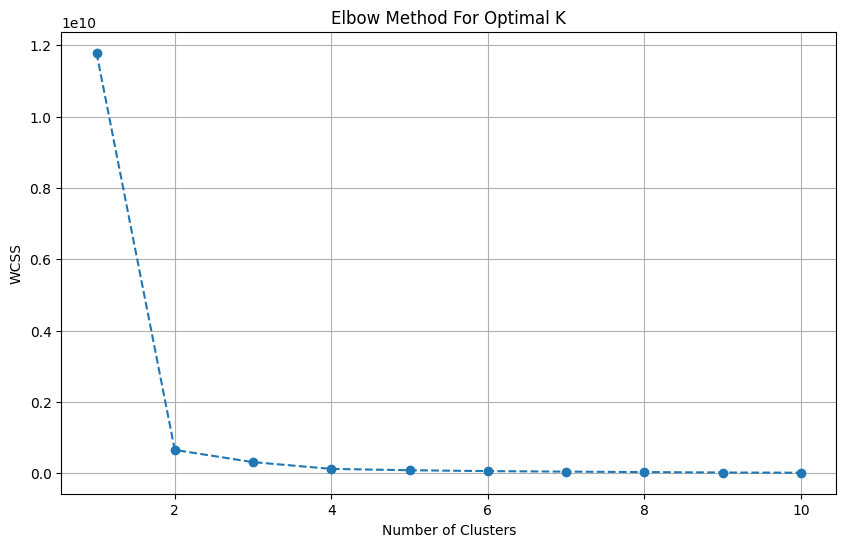

Based on the elbow plot, choose an appropriate number of clusters (e.g., 3 or 4).
K-Means clustering applied with 3 clusters.
Silhouette Score for K-Means: 0.87

K-Means Cluster Analysis (Mean values by cluster):


,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,CO2_Emissions (in MT),Industrial_Waste (in tons),Energy_Recovered (in GWh),Energy_Recovery_Per_Capita
KMeans_Cluster,,,,,,,
0,0.007711,-0.005454,0.001232,-0.011113,-0.002331,259.166753,160.117757
1,0.826287,0.789517,-0.942293,-0.309539,1.036005,239.690000,105717.126165
2,-0.464431,0.053725,0.140666,0.493111,-0.116771,314.340000,-8220.268427


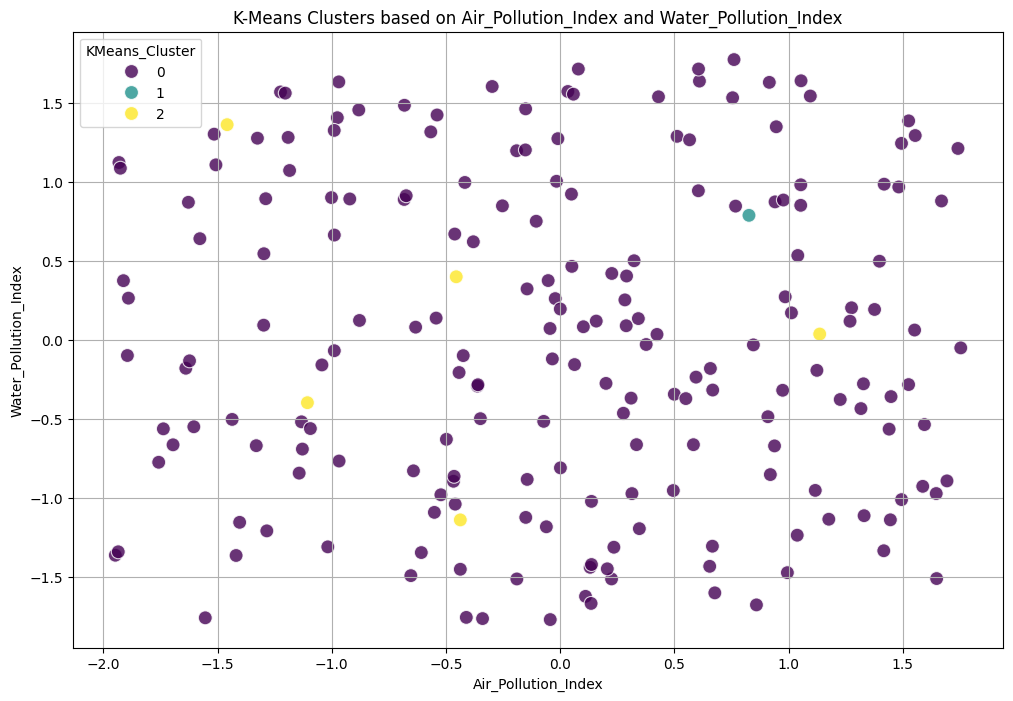


DataFrame head after K-Means clustering:


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Country_Encoded,Energy_Recovery_Per_Capita,KMeans_Cluster
0,Hungary,2005,1.376167,0.193880,-0.619764,1.543328,158.14,-1.356325,1.079423,0.874923,0.561742,-1.093143,-0.737646,77,-144.665453,0
1,Singapore,2001,-1.403578,-1.153098,1.028744,0.124915,498.04,-1.284276,0.700701,0.600289,-0.756197,0.580978,-0.023527,147,857.244431,0
2,Romania,2016,-1.330788,-0.668076,1.142400,0.123888,489.51,1.718910,-1.493780,-0.395504,0.667825,0.355836,1.156054,136,1375.663231,0
3,Cook Islands,2018,1.494394,-1.009403,0.431675,0.809131,145.18,-1.106232,-0.716061,-1.064327,-1.556310,-0.642506,-0.693157,38,-225.958940,0
4,Djibouti,2008,-0.021926,0.262567,1.138106,0.882681,40.38,-0.689181,0.502825,1.024815,0.612087,1.448956,0.312447,46,27.868350,0


In [ ]:
# Import KMeans for clustering and metrics for evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define features for clustering. These typically include the scaled pollution indices and energy recovery metrics.
# We will use the scaled columns and the engineered 'Energy_Recovery_Per_Capita'
clustering_features = [
    'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index',
    'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)',
    'Energy_Recovered (in GWh)', 'Energy_Recovery_Per_Capita' # Updated column names
]

# Filter for existing columns in case some were not created or scaled
actual_clustering_features = [col for col in clustering_features if col in df.columns]

X = df[actual_clustering_features]

# Use Elbow Method to determine the optimal number of clusters
print("\n--- K-Means Clustering ---")
print("Determining optimal number of clusters using Elbow Method...")

wcss = [] # Within-Cluster Sum of Squares
for i in range(1, min(11, len(X))): # Iterate up to 10 clusters or number of samples if less
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, min(11, len(X))), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

print("Based on the elbow plot, choose an appropriate number of clusters (e.g., 3 or 4).")
# For demonstration, let's assume optimal_k = 3 if there are enough samples.
optimal_k = min(3, len(X)) # Ensure optimal_k is not 0 for very small datasets
if optimal_k == 0 and len(X) > 0: # If X has data but optimal_k became 0, default to 1
    optimal_k = 1

if optimal_k > 0: # Ensure optimal_k is valid for clustering
    # Apply K-Means with the chosen number of clusters
    kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
    df['KMeans_Cluster'] = kmeans.fit_predict(X)
    print(f"K-Means clustering applied with {optimal_k} clusters.")

    # Evaluate K-Means
    if len(X) >= 2 and optimal_k > 1: # Silhouette score requires at least 2 samples and >1 cluster
        silhouette_avg = silhouette_score(X, df['KMeans_Cluster'])
        print(f"Silhouette Score for K-Means: {silhouette_avg:.2f}")

    # Visualize pollution trends and energy recovery by clusters
    print("\nK-Means Cluster Analysis (Mean values by cluster):")
    # Removed 'Country' from the mean calculation as it's a non-numeric column
    display(df.groupby('KMeans_Cluster')[actual_clustering_features].mean())

    # Optionally visualize with a pairplot or specific scatter plots if actual_clustering_features has 2-3 dimensions
    if len(actual_clustering_features) >= 2:
        plt.figure(figsize=(12, 8))
        sns.scatterplot(x=actual_clustering_features[0], y=actual_clustering_features[1], hue='KMeans_Cluster', data=df, palette='viridis', s=100, alpha=0.8)
        plt.title(f'K-Means Clusters based on {actual_clustering_features[0]} and {actual_clustering_features[1]}')
        plt.grid(True)
        plt.show()
    print("\nDataFrame head after K-Means clustering:")
    display(df.head())
else:
    print("Not enough data points to perform K-Means clustering.")

### Hierarchical Clustering


--- Hierarchical Clustering ---


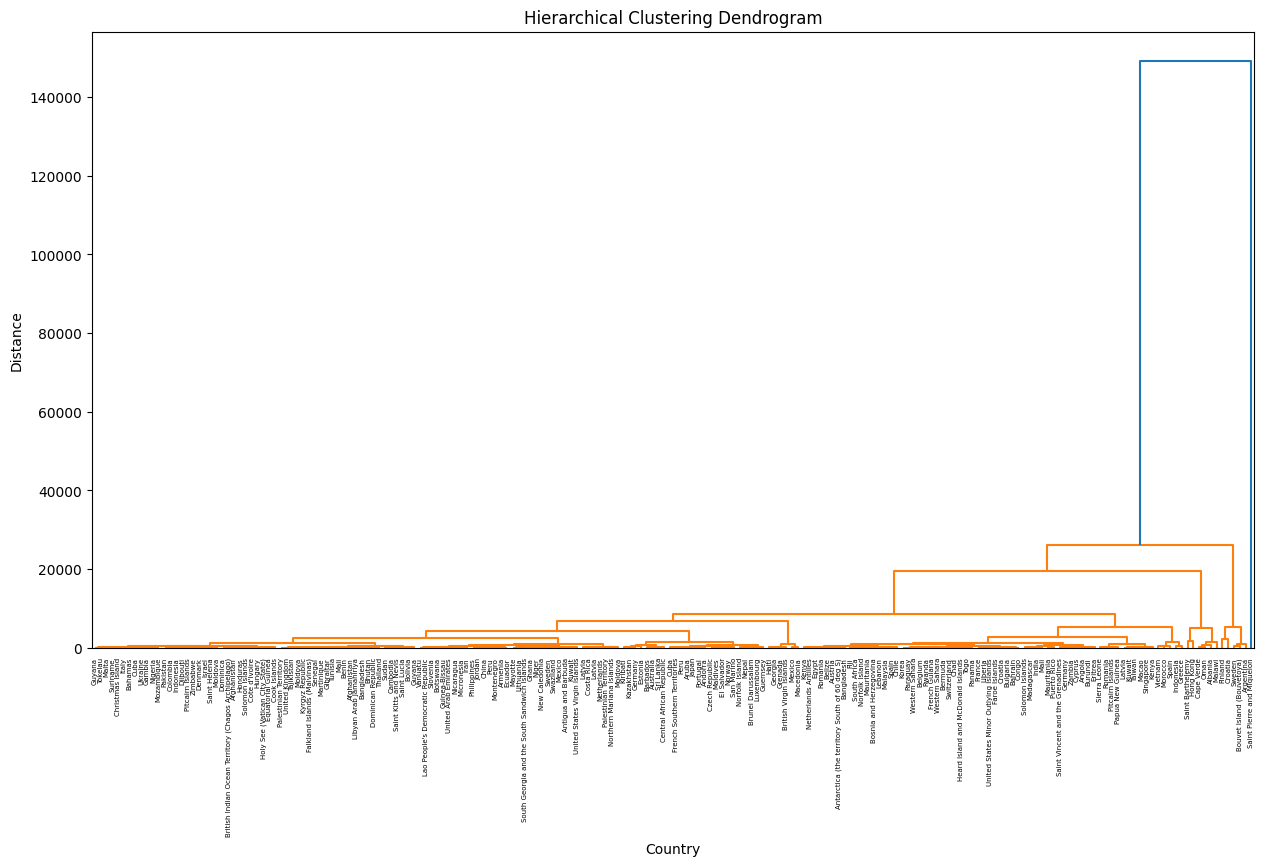

Based on the dendrogram, determine the number of clusters by cutting the tree.
Hierarchical clustering applied with 3 clusters.
Silhouette Score for Hierarchical Clustering: 0.87

Hierarchical Cluster Analysis (Mean values by cluster):


,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,CO2_Emissions (in MT),Industrial_Waste (in tons),Energy_Recovered (in GWh),Energy_Recovery_Per_Capita
Hierarchical_Cluster,,,,,,,
0,0.007711,-0.005454,0.001232,-0.011113,-0.002331,259.166753,160.117757
1,0.826287,0.789517,-0.942293,-0.309539,1.036005,239.690000,105717.126165
2,-0.464431,0.053725,0.140666,0.493111,-0.116771,314.340000,-8220.268427


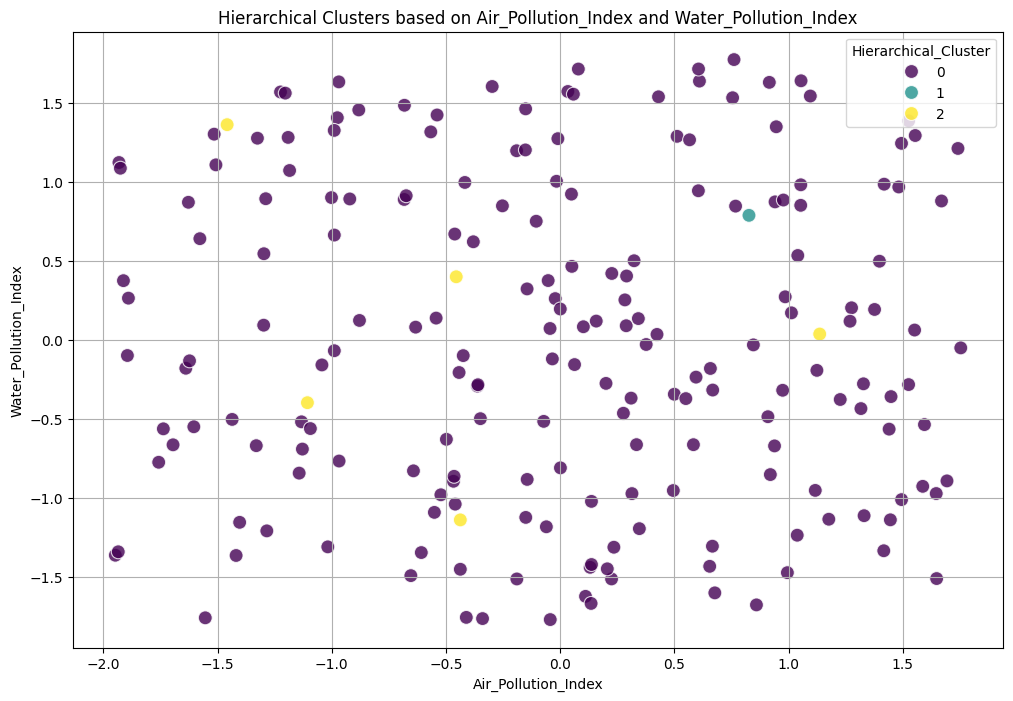


--- Clustering Comparison ---
You can now compare the KMeans_Cluster and Hierarchical_Cluster columns in the DataFrame to see how assignments differ.


,Country,KMeans_Cluster,Hierarchical_Cluster
0,Hungary,0,0
1,Singapore,0,0
2,Romania,0,0
3,Cook Islands,0,0
4,Djibouti,0,0


In [ ]:
# Import AgglomerativeClustering and dendrogram for visualization
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

print("\n--- Hierarchical Clustering ---")

# Perform hierarchical clustering
# Using 'ward' linkage for minimizing variance within clusters
if len(X) >= 2:
    linked = linkage(X, method='ward')

    # Plotting the dendrogram
    plt.figure(figsize=(15, 8))
    dendrogram(linked,
               orientation='top',
               labels=df['Country'].values,
               distance_sort='descending',
               show_leaf_counts=True)
    plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Country')
    plt.ylabel('Distance')
    plt.show()

    print("Based on the dendrogram, determine the number of clusters by cutting the tree.")
    # For demonstration, let's assume we cut to get optimal_k clusters, same as K-Means if possible
    # Make sure optimal_k is valid for AgglomerativeClustering
    if optimal_k > 1:
        # Changed 'affinity' to 'metric' as 'affinity' is deprecated/removed in newer scikit-learn versions
        h_cluster = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
        df['Hierarchical_Cluster'] = h_cluster.fit_predict(X)
        print(f"Hierarchical clustering applied with {optimal_k} clusters.")

        # Evaluate Hierarchical Clustering
        silhouette_avg_hc = silhouette_score(X, df['Hierarchical_Cluster'])
        print(f"Silhouette Score for Hierarchical Clustering: {silhouette_avg_hc:.2f}")

        # Compare the results with K-Means (e.g., by comparing cluster assignments or statistics)
        print("\nHierarchical Cluster Analysis (Mean values by cluster):")
        # Removed 'Country' from the mean calculation as it's a non-numeric column
        display(df.groupby('Hierarchical_Cluster')[actual_clustering_features].mean())

        # Visual comparison (if possible)
        if len(actual_clustering_features) >= 2:
            plt.figure(figsize=(12, 8))
            sns.scatterplot(x=actual_clustering_features[0], y=actual_clustering_features[1], hue='Hierarchical_Cluster', data=df, palette='viridis', s=100, alpha=0.8)
            plt.title(f'Hierarchical Clusters based on {actual_clustering_features[0]} and {actual_clustering_features[1]}')
            plt.grid(True)
            plt.show()
    else:
        print("Not enough clusters (optimal_k <= 1) to perform meaningful Hierarchical Clustering.")
else:
    print("Not enough data points to perform Hierarchical Clustering.")

print("\n--- Clustering Comparison ---")
print("You can now compare the KMeans_Cluster and Hierarchical_Cluster columns in the DataFrame to see how assignments differ.")
display(df[['Country', 'KMeans_Cluster', 'Hierarchical_Cluster']].head())

## Phase 3: Neural Networks for Energy Recovery Prediction

### Introduction to Neural Networks


--- Neural Network for Energy Recovery Prediction ---
Using 11 features for prediction: Air_Pollution_Index, Water_Pollution_Index, Soil_Pollution_Index, CO2_Emissions (in MT), Industrial_Waste (in tons), Renewable_Energy (%), Plastic_Waste_Produced (in tons), Energy_Consumption_Per_Capita (in MWh), Population (in millions), GDP_Per_Capita (in USD), Country_Encoded
Training data shape: (160, 11), Test data shape: (40, 11)

Training Neural Network model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network model training complete.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step 

Neural Network Evaluation on Test Set:
R-squared (R²): -0.3460
Mean Squared Error (MSE): 32549.0462
Mean Absolute Error (MAE): 161.2094
Stored 'model' (Sequential)
Stored 'nn_results' (dict)

Neural Network Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,645 (33.77 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,764 (22.52 KB)

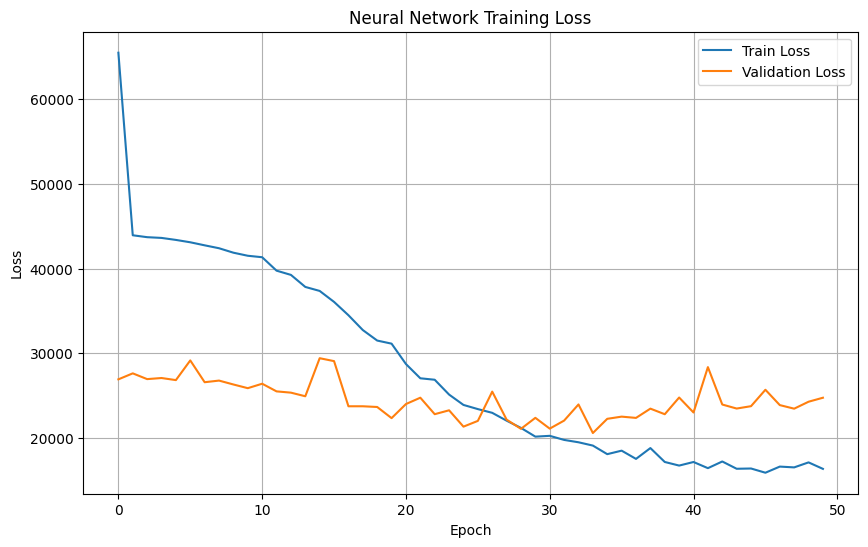


Linear Regression Evaluation on Test Set (for comparison):
R-squared (R²): -0.1158
Mean Squared Error (MSE): 26982.9517
Mean Absolute Error (MAE): 146.2949
Stored 'lr_model' (LinearRegression)
Stored 'lr_results' (dict)


In [ ]:
# Import necessary libraries for Neural Networks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("\n--- Neural Network for Energy Recovery Prediction ---")

# Define features (X) and target (y)
# Input features: Air_Pollution_Index, CO2_Emissions, Industrial_Waste, etc.
# Output: Energy_Recovered (in GWh).

# Using the scaled numerical features and Country_Encoded as input features
# We exclude 'Energy_Recovered (in GWh)' from X as it is our target variable.
# Also exclude original 'Country' and 'Year' as we have encoded/processed them.

feature_cols = [
    'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index',
    'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)',
    'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
    'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)', 'GDP_Per_Capita (in USD)',
    'Country_Encoded' # Ensure this is present if 'Country' was encoded
]

target_col = 'Energy_Recovered (in GWh)' # Updated target column name

# Ensure all feature columns exist in the DataFrame
actual_feature_cols = [col for col in feature_cols if col in df.columns]

if target_col in df.columns and len(actual_feature_cols) > 0:
    X = df[actual_feature_cols]
    y = df[target_col]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"Using {len(actual_feature_cols)} features for prediction: {', '.join(actual_feature_cols)}")
    print(f"Training data shape: {X_train.shape}, Test data shape: {X_test.shape}")

    # Build the neural network model
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1) # Output layer for regression
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    print("\nTraining Neural Network model...")
    history = model.fit(X_train, y_train, epochs=50, batch_size=1, verbose=0, validation_split=0.2)
    print("Neural Network model training complete.")

    # Evaluate the model
    y_pred_nn = model.predict(X_test).flatten()

    r2_nn = r2_score(y_test, y_pred_nn)
    mse_nn = mean_squared_error(y_test, y_pred_nn)
    mae_nn = mean_absolute_error(y_test, y_pred_nn)

    print(f"\nNeural Network Evaluation on Test Set:")
    print(f"R-squared (R²): {r2_nn:.4f}")
    print(f"Mean Squared Error (MSE): {mse_nn:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_nn:.4f}")

    # Store results for comparison later
    nn_results = {'R2': r2_nn, 'MSE': mse_nn, 'MAE': mae_nn} # Define nn_results before storing
    %store model
    %store nn_results

    print("\nNeural Network Model Summary:")
    model.summary()

    # Optionally plot training history
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Neural Network Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Also, for comparison, we can quickly train a Linear Regression model
    from sklearn.linear_model import LinearRegression
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)

    r2_lr = r2_score(y_test, y_pred_lr)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    mae_lr = mean_absolute_error(y_test, y_pred_lr)

    print(f"\nLinear Regression Evaluation on Test Set (for comparison):")
    print(f"R-squared (R²): {r2_lr:.4f}")
    print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")

    lr_results = {'R2': r2_lr, 'MSE': mse_lr, 'MAE': mae_lr}

    # Store models and results in the kernel state for later use
    %store lr_model
    %store lr_results

else:
    print(f"Required columns for NN prediction ('{target_col}' or {', '.join(feature_cols)}) not found. Skipping Neural Network phase.")

### Model Improvement (Hyperparameter Tuning - Conceptual)


--- Model Improvement: Hyperparameter Tuning (Conceptual) ---

To improve the neural network model, we would typically perform hyperparameter tuning.
This involves experimenting with different:
  - Number of layers: Add or remove `Dense` layers.
  - Number of neurons per layer: Adjust the first argument in `Dense(units, ...)`.
  - Activation functions: Try `sigmoid`, `tanh`, `softmax` (though `relu` is often good for hidden layers).
  - Optimizers: Experiment with `sgd`, `rmsprop`, `adagrad`, etc., instead of `adam`.
  - Learning rates: This can be adjusted within the optimizer configuration (e.g., `tf.keras.optimizers.Adam(learning_rate=0.001)`).
  - Epochs and Batch Size: Increase `epochs` for more training iterations, adjust `batch_size` for different gradient update frequencies.
  - Regularization: Add `Dropout` layers or L1/L2 regularization to prevent overfitting.

Techniques for tuning include:
  - Grid Search or Random Search (e.g., using `sklearn.model_selection.GridSearchCV` or `RandomizedSearchCV` if wrapping Keras models with `KerasRegressor`).
  - Bayesian Optimization (e.g., using libraries like `Hyperopt` or `Keras Tuner`).
The goal is to find the combination of hyperparameters that minimizes the validation loss and provides the best performance on unseen data, balancing bias and variance.


## Phase 4: Reporting and Insights

### Model Comparison

--- Model Comparison ---

Predictive Model Performance Comparison:

Below is the comparison of the Neural Network and Linear Regression models' performance based on R-squared, Mean Squared Error (MSE), and Mean Absolute Error (MAE). A separate code cell will execute the comparison logic and display the results.

Clustering Model Comparison:
K-Means Clustering:
  - Strengths: Computationally efficient, scales well to large datasets, easy to understand and implement. Good for identifying spherical, well-separated clusters.
  - Weaknesses: Requires pre-specification of the number of clusters (k), sensitive to initial centroid placement, struggles with non-spherical or unevenly sized clusters, sensitive to outliers.
Hierarchical Clustering:
  - Strengths: Does not require pre-specification of k, provides a dendrogram for visual interpretation of cluster structure, can reveal relationships at different levels of granularity.
  - Weaknesses: Computationally more expensive (especially for large datasets), results can be sensitive to the choice of distance metric and linkage method, determining the optimal number of clusters from a dendrogram can be subjective.

Which model offers better predictions and clustering results depends on the specific goals:
  - For predictive tasks (energy recovery): A properly tuned Neural Network would likely offer superior performance if complex, non-linear relationships exist and sufficient data is available. Linear Regression serves as a strong, interpretable baseline.
  - For understanding country groupings: Both K-Means and Hierarchical Clustering provide valuable insights. Hierarchical clustering offers a more detailed view of the relationships between individual data points/countries through its dendrogram, while K-Means provides clear, distinct group assignments.

try:
    # Reload stored results
    %store -r nn_results
    %store -r lr_results

    print("Predictive Model Performance Comparison:")
    print("\nNeural Network (NN):")
    print(f"  R-squared (R²): {nn_results['R2']:.4f}")
    print(f"  Mean Squared Error (MSE): {nn_results['MSE']:.4f}")
    print(f"  Mean Absolute Error (MAE): {nn_results['MAE']:.4f}")

    print("\nLinear Regression (LR):")
    print(f"  R-squared (R²): {lr_results['R2']:.4f}")
    print(f"  Mean Squared Error (MSE): {lr_results['MSE']:.4f}")
    print(f"  Mean Absolute Error (MAE): {lr_results['MAE']:.4f}")

    # Decide which model is better based on R-squared
    if nn_results['R2'] > lr_results['R2']:
        print("\nConclusion: The Neural Network model performed better based on R-squared.")
    else:
        print("\nConclusion: The Linear Regression model performed better based on R-squared.")

except NameError as e:
    print(f"Could not retrieve predictive model results. Please ensure the Neural Network phase was run successfully. Error: {e}")
except KeyError as e:
    print(f"Error accessing model results. Key missing: {e}. Please ensure results are properly stored.")

--- Actionable Insights ---


Insights from Clustering (K-Means and Hierarchical):
  - By grouping countries based on their pollution levels and energy recovery metrics, we can identify archetypes of environmental performance.
  - For example, a cluster with high pollution indices and low energy recovery might indicate countries in urgent need of environmental policy intervention and investment in sustainable practices.
  - Conversely, a cluster with low pollution and high energy recovery could serve as a benchmark, and their strategies can be studied for best practices.
  - **Recommendation:** Tailor environmental policies and resource allocation based on cluster characteristics. Countries in 'high pollution, low recovery' clusters require targeted assistance in waste management, cleaner energy adoption, and pollution control technologies.

Insights from Neural Network Prediction:
  - The neural network model helps quantify the impact of various pollution factors on energy recovery. Analyzing feature importance (e.g., through techniques like SHAP or LIME, though not implemented here) could reveal which specific pollution types or industrial activities have the most significant negative or positive correlation with energy recovery.
  - **Recommendation:** Focus on reducing the pollution sources that have the strongest negative impact on energy recovery, as identified by the predictive model. For instance, if CO2 emissions show a strong inverse relationship with energy recovery, policies promoting carbon capture or renewable energy would be crucial.

General Recommendations:
1. **Data-Driven Policy Making:** Use these models to inform policy decisions, ensuring interventions are evidence-based and targeted.
2. **International Collaboration:** Countries within similar clusters can collaborate on solutions, sharing technologies and strategies.
3. **Investment in Green Technologies:** Promote R&D and adoption of technologies that simultaneously reduce pollution and enhance energy recovery, such as advanced waste-to-energy systems, and efficient industrial processes.
4. **Public Awareness & Education:** Increase awareness about the correlation between pollution and energy sustainability to foster public support for environmental initiatives.
5. **Continuous Monitoring & Evaluation:** Regularly update the data and re-run the models to monitor progress, adapt strategies, and ensure long-term environmental sustainability.
